In [2]:
from random import random, randint, sample
from collections import namedtuple

# Calcula el capital invertido por un individuo
def capitalInvertido(individuo):
    return sum(map(lambda x, y: x*y.precio, individuo, inversiones))

# Calcula el rendimiento obtenido por un individuo
def rendimiento(individuo):
    return sum(map(lambda x, y: x*y.precio*y.rendim,
                               individuo, inversiones))

# Si un individuo gasta más capital del disponible, se eliminan
# aleatoriamente inversiones hasta que se ajusta al capital
def ajustaCapital(individuo):
    ajustado = individuo[:]
    while capitalInvertido(ajustado) > capital:
        pos = randint(0, len(ajustado)-1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1

    return ajustado

# Crea un individuo al azar, en este caso una selección de
# inversiones que no excedan el capital disponible
def creaIndividuo(inversiones, capital):
    individuo = [0] * len(inversiones)

    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones)-1)
        individuo[eleccion] += 1

    return ajustaCapital(individuo)

# Crea un nuevo individuo cruzando otros dos (cuyas posiciones se
# indican en el segundo parámetro)
def cruza(poblacion, posiciones):
    L = len(poblacion[0])

    # Toma los genes del primer progenitor y luego toma al azar
    # un segmento de entre 1 y L genes del segundo progenitor
    hijo    = poblacion[posiciones[0]][:]
    inicio  = randint(0, L-1)
    fin     = randint(inicio+1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]

    return ajustaCapital(hijo)

# Aplica mutaciones a un individuo según una tasa dada; garantiza
# que cumple las restricciones de capital e inversiones
def muta(individuo, tasaMutacion):
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))

    return ajustaCapital(mutado)

# Hace evolucionar el sistema durante un número de generaciones
def evoluciona(poblacion, generaciones):

    # Ordena la población inicial por rendimiento producido
    poblacion.sort(key=lambda x: rendimiento(x))

    # Algunos valores útiles
    N            = len(poblacion)
    tasaMutacion = 0.01

    # Genera una lista del tipo [0,1,1,2,2,2,3,3,3,3,...] para
    # representar las probabilidades de reproducirse de cada
    # individuo (el primero 1 posibilidad, el segundo 2, etc.)
    reproduccion = [x for x in range(N) for y in range(x+1)]

    for i in range(generaciones):
        # Se generan N-1 nuevos individuos cruzando los existentes
        # (sin que se repitan los padres)
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)
        hijos = [cruza(poblacion, padres) for x in range(N-1)]

        # Se aplican mutaciones con una cierta probabilidad
        hijos = [muta(x, tasaMutacion) for x in hijos]

        # Se añade el mejor individuo de la población anterior
        # (elitismo)
        hijos.append(poblacion[-1])
        poblacion = hijos

        # Se ordenan los individuos por rendimiento
        poblacion.sort(key=lambda x: rendimiento(x))

    # Devuelve el mejor individuo encontrado
    return poblacion[-1]

# Declara una tupla con nombres para representar cada inversión
Inversion = namedtuple('Inversion', 'precio cantidad rendim')

numInver  = 100
maxPrecio = 1000
maxCant   = 10
maxRend   = 0.2

# Genera una lista de tuplas Inversion
inversiones = [Inversion(random()*maxPrecio, randint(1, maxCant),
                         random()*maxRend) for i in range(numInver)]
print(inversiones)

capital      = 50000
individuos   = 20
generaciones = 1000

poblacion = [creaIndividuo(inversiones, capital)
                           for i in range(individuos)]

# Nota: para simplificar el programa se accede a inversiones y
# capital de forma global (sólo se leen, no se modifican)

mejor = evoluciona(poblacion, generaciones)
print(mejor, capitalInvertido(mejor), rendimiento(mejor))

[Inversion(precio=186.96515442687368, cantidad=3, rendim=0.12026753178723387), Inversion(precio=318.1561544354884, cantidad=6, rendim=0.0670044118671174), Inversion(precio=615.3028603686881, cantidad=7, rendim=0.19590594237174822), Inversion(precio=531.5673052419049, cantidad=2, rendim=0.06941123156220552), Inversion(precio=862.4136128149147, cantidad=6, rendim=0.026299146603535252), Inversion(precio=329.66371857992215, cantidad=10, rendim=0.11511306170439291), Inversion(precio=438.96328207702396, cantidad=3, rendim=0.11857005057592351), Inversion(precio=278.9393933963478, cantidad=9, rendim=0.02347373981278955), Inversion(precio=542.0538806695337, cantidad=4, rendim=0.13858918469083523), Inversion(precio=956.8240069737212, cantidad=2, rendim=0.15693310578510775), Inversion(precio=792.9145945721639, cantidad=8, rendim=0.03981251112020297), Inversion(precio=615.8627197920091, cantidad=6, rendim=0.09764850744618031), Inversion(precio=410.3143355823357, cantidad=3, rendim=0.13777814393996

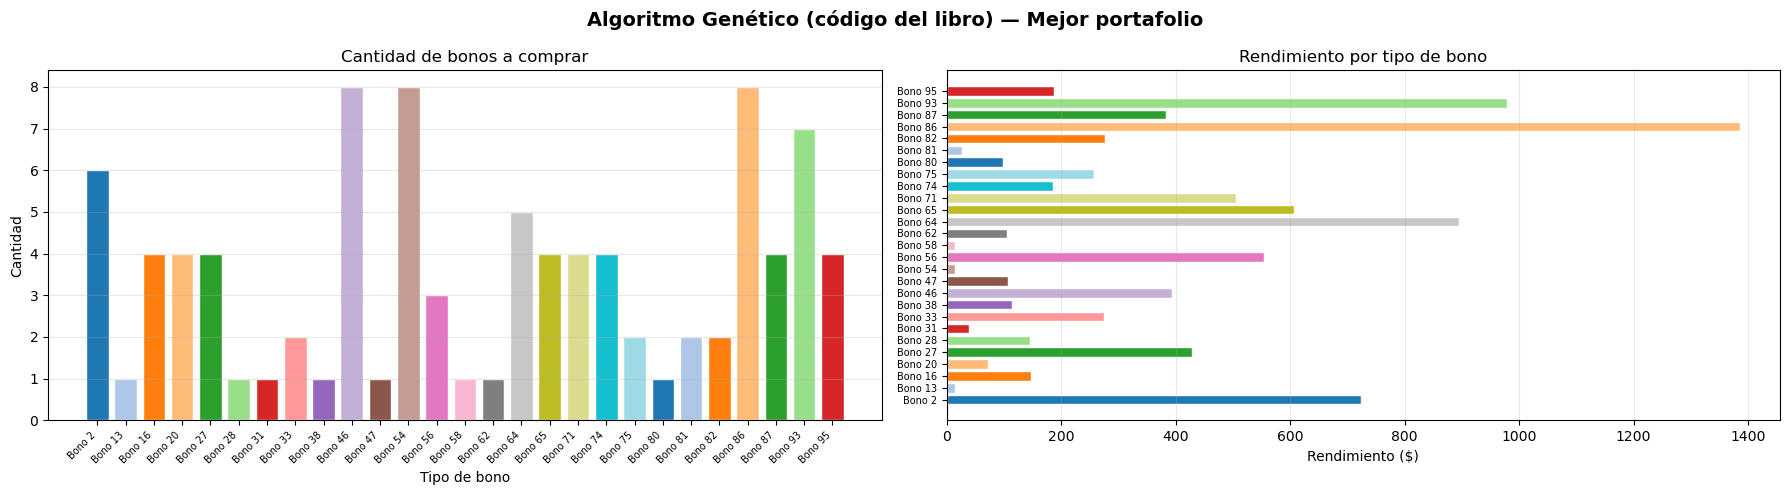


  Capital disponible : $   50,000.00
  Capital invertido  : $   49,989.34
  Capital restante   : $       10.66
  Rendimiento total  : $    8,943.21
  Tipos de bonos     : 27 (de 100 disponibles)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def graficar_resultado(mejor, inversiones, titulo="Mejor portafolio"):
    """Muestra en forma gráfica la cantidad de bonos a comprar por tipo."""
    # Filtrar sólo los bonos con cantidad > 0
    indices = [i for i, q in enumerate(mejor) if q > 0]
    cantidades = [mejor[i] for i in indices]
    etiquetas  = [f"Bono {i}" for i in indices]
    precios    = [inversiones[i].precio for i in indices]
    rendims    = [inversiones[i].rendim * 100 for i in indices]  # en %

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    # Gráfico 1: Cantidad de bonos por tipo
    colors = plt.cm.tab20.colors
    axes[0].bar(range(len(indices)), cantidades,
                color=[colors[i % 20] for i in range(len(indices))],
                edgecolor='white')
    axes[0].set_title('Cantidad de bonos a comprar')
    axes[0].set_xlabel('Tipo de bono')
    axes[0].set_ylabel('Cantidad')
    axes[0].set_xticks(range(len(indices)))
    axes[0].set_xticklabels(etiquetas, rotation=45, ha='right', fontsize=7)
    axes[0].grid(axis='y', alpha=0.3)

    # Gráfico 2: Rendimiento por tipo de bono
    rendim_por_bono = [mejor[i] * inversiones[i].precio * inversiones[i].rendim
                       for i in indices]
    axes[1].barh(range(len(indices)), rendim_por_bono,
                 color=[colors[i % 20] for i in range(len(indices))],
                 edgecolor='white')
    axes[1].set_title('Rendimiento por tipo de bono')
    axes[1].set_xlabel('Rendimiento ($)')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels(etiquetas, fontsize=7)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print(f"\n{'='*50}")
    print(f"  Capital disponible : ${capital:>12,.2f}")
    print(f"  Capital invertido  : ${capitalInvertido(mejor):>12,.2f}")
    print(f"  Capital restante   : ${capital - capitalInvertido(mejor):>12,.2f}")
    print(f"  Rendimiento total  : ${rendimiento(mejor):>12,.2f}")
    print(f"  Tipos de bonos     : {len(indices)} (de {len(inversiones)} disponibles)")
    print(f"{'='*50}")

graficar_resultado(mejor, inversiones,
                   titulo="Algoritmo Genético (código del libro) — Mejor portafolio")

**Usando DEAP**

In [9]:
import subprocess
subprocess.run(['pip', 'install', 'deap', '-q'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'deap', '-q'], returncode=0, stdout=b'', stderr=b'')

In [18]:
import random
import numpy as np
from collections import namedtuple
from deap import base, creator, tools, algorithms

def evalPortafolio(individuo):
    """Devuelve el rendimiento; penaliza si excede el capital."""
    cap_usado = sum(x * y.precio for x, y in zip(individuo, inversiones))
    if cap_usado > capital:
        return (-1.0,)   # penalización
    rend = sum(x * y.precio * y.rendim for x, y in zip(individuo, inversiones))
    return (rend,)

# Limpiar clases previas si la celda se re-ejecuta
if 'FitnessMax' in dir(creator): del creator.FitnessMax
if 'Individual' in dir(creator): del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Gen: cantidad de un bono (entero entre 0 y maxCant)
toolbox.register("attr_bono", random.randint, 0, maxCant)

# Individuo: lista de numInver genes
toolbox.register("individual", tools.initRepeat,
                 creator.Individual, toolbox.attr_bono, n=numInver)

# Población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Operadores
toolbox.register("evaluate", evalPortafolio)
toolbox.register("mate",     tools.cxTwoPoint)          
toolbox.register("mutate",   tools.mutUniformInt,       
                 low=0, up=maxCant, indpb=0.01)
toolbox.register("select",   tools.selTournament, tournsize=3)  

# Ejecución
random.seed(42)

pop_deap  = toolbox.population(n=20)
hof       = tools.HallOfFame(1)          
stats     = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max",  np.max)
stats.register("mean", np.mean)

pop_final, log = algorithms.eaSimple(
    pop_deap, toolbox,
    cxpb=0.7,          
    mutpb=0.01,        
    ngen=1000,         
    stats=stats,
    halloffame=hof,
    verbose=False
)

mejor_deap = hof[0]
cap_deap   = sum(x * y.precio for x, y in zip(mejor_deap, inversiones))
rend_deap  = mejor_deap.fitness.values[0]

print(f"Capital invertido (DEAP) : ${cap_deap:,.2f}")
print(f"Rendimiento      (DEAP) : ${rend_deap:,.2f}")

Capital invertido (DEAP) : $262,892.88
Rendimiento      (DEAP) : $-1.00


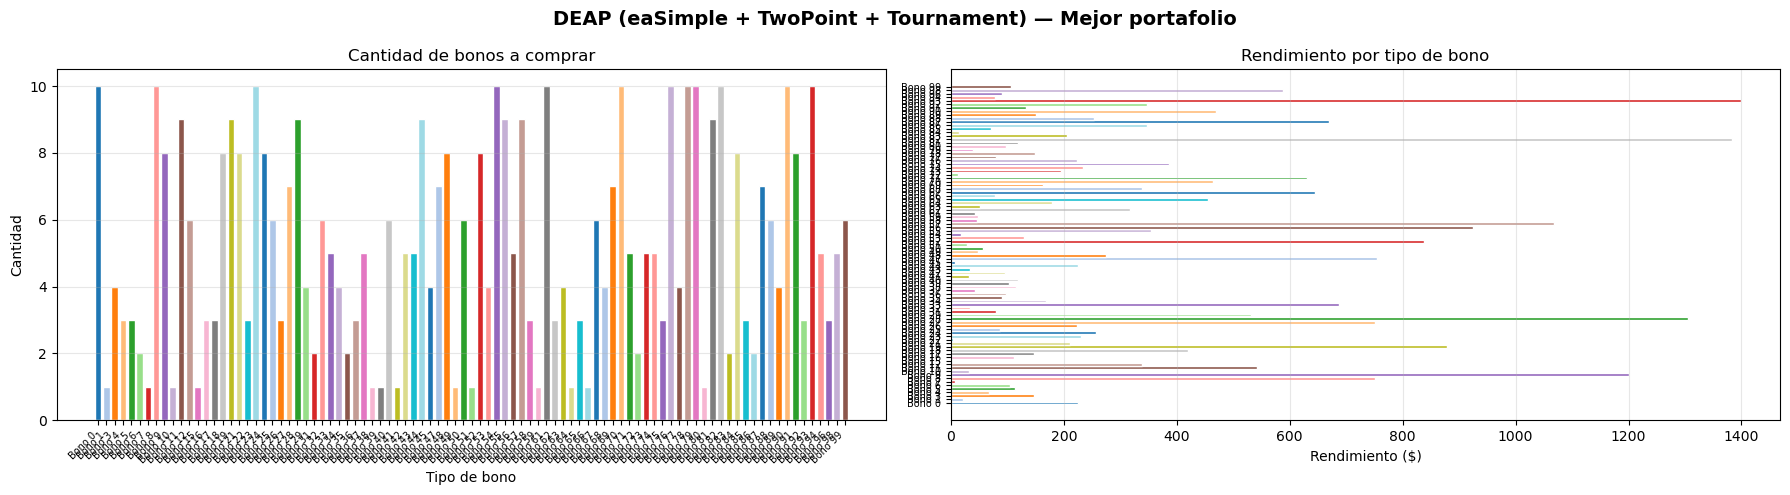


  Capital disponible : $   50,000.00
  Capital invertido  : $  262,892.88
  Capital restante   : $ -212,892.88
  Rendimiento total  : $   26,427.97
  Tipos de bonos     : 91 (de 100 disponibles)


In [19]:
# Visualización del resultado DEAP
def capitalInvertido_deap(ind):
    return sum(x * y.precio for x, y in zip(ind, inversiones))

def rendimiento_deap(ind):
    return sum(x * y.precio * y.rendim for x, y in zip(ind, inversiones))

graficar_resultado(list(mejor_deap), inversiones,
                   titulo="DEAP (eaSimple + TwoPoint + Tournament) — Mejor portafolio")

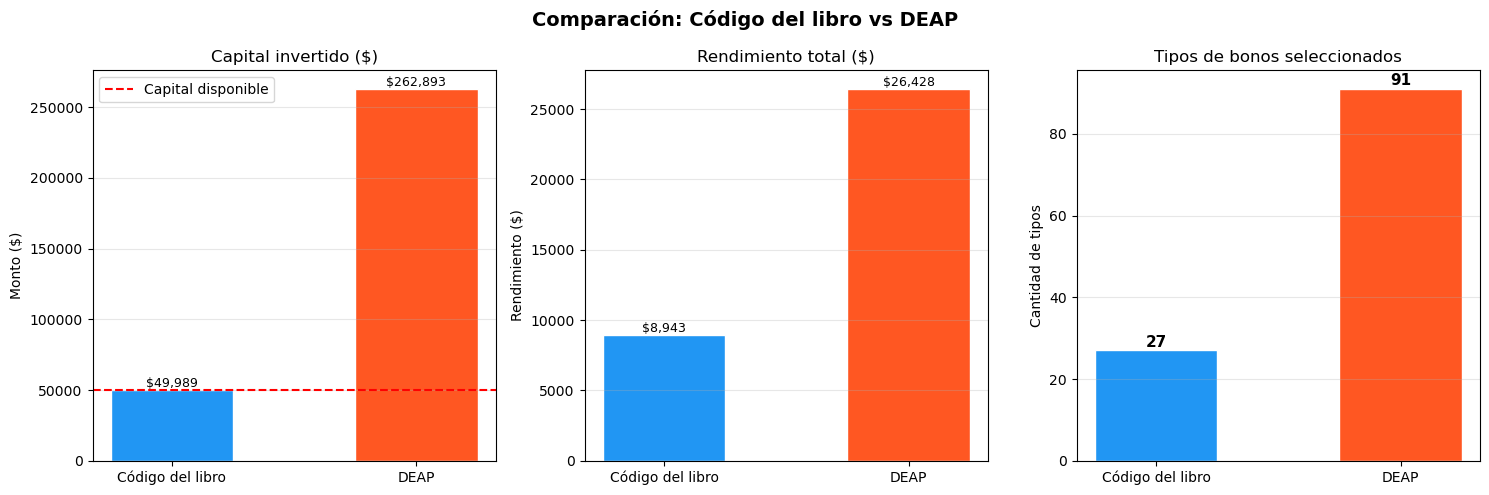


                    COMPARACIÓN DE SOLUCIONES                    
Métrica                           Código libro            DEAP
-----------------------------------------------------------------
Capital invertido ($)                49,989.34      262,892.88
Rendimiento total ($)                 8,943.21       26,427.97
Tipos de bonos usados                       27              91
Capital sin invertir ($)                 10.66     -212,892.88


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Métricas comparativas ─────────────────────────────────────────
cap_libro  = capitalInvertido(mejor)
rend_libro = rendimiento(mejor)
cap_deap_  = sum(x * y.precio for x, y in zip(mejor_deap, inversiones))
rend_deap_ = sum(x * y.precio * y.rendim for x, y in zip(mejor_deap, inversiones))

labels     = ['Código del libro', 'DEAP']
cap_vals   = [cap_libro,  cap_deap_]
rend_vals  = [rend_libro, rend_deap_]
bonos_vals = [sum(1 for q in mejor        if q > 0),
              sum(1 for q in mejor_deap   if q > 0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparación: Código del libro vs DEAP', fontsize=14, fontweight='bold')

colores = ['#2196F3', '#FF5722']

# Capital invertido
bars0 = axes[0].bar(labels, cap_vals, color=colores, edgecolor='white', width=0.5)
axes[0].set_title('Capital invertido ($)')
axes[0].set_ylabel('Monto ($)')
axes[0].axhline(y=capital, color='red', linestyle='--', label='Capital disponible')
axes[0].legend()
for bar, v in zip(bars0, cap_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Rendimiento total
bars1 = axes[1].bar(labels, rend_vals, color=colores, edgecolor='white', width=0.5)
axes[1].set_title('Rendimiento total ($)')
axes[1].set_ylabel('Rendimiento ($)')
for bar, v in zip(bars1, rend_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Tipos de bonos seleccionados
bars2 = axes[2].bar(labels, bonos_vals, color=colores, edgecolor='white', width=0.5)
axes[2].set_title('Tipos de bonos seleccionados')
axes[2].set_ylabel('Cantidad de tipos')
for bar, v in zip(bars2, bonos_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tabla de diferencias ──────────────────────────────────────────
print("\n" + "="*65)
print(f"{'COMPARACIÓN DE SOLUCIONES':^65}")
print("="*65)
print(f"{'Métrica':<30} {'Código libro':>15} {'DEAP':>15}")
print("-"*65)
print(f"{'Capital invertido ($)':<30} {cap_libro:>15,.2f} {cap_deap_:>15,.2f}")
print(f"{'Rendimiento total ($)':<30} {rend_libro:>15,.2f} {rend_deap_:>15,.2f}")
print(f"{'Tipos de bonos usados':<30} {bonos_vals[0]:>15} {bonos_vals[1]:>15}")
print(f"{'Capital sin invertir ($)':<30} {capital-cap_libro:>15,.2f} {capital-cap_deap_:>15,.2f}")
print("="*65)